In [2]:
"""
PRISM: Photometric Recognition with Instance-adaptive Self-Attention Mechanism
Final optimized architecture: Graph Encoder + Mutual Info Attention + Calibrated LightGBM
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.calibration import CalibratedClassifierCV
import lightgbm as lgb

# Load preprocessed data
X_train = joblib.load('../models/X_train.pkl')
X_val = joblib.load('../models/X_val.pkl')
X_test = joblib.load('../models/X_test.pkl')
y_train = joblib.load('../models/y_train.pkl')
y_val = joblib.load('../models/y_val.pkl')
y_test = joblib.load('../models/y_test.pkl')
feature_names = joblib.load('../models/feature_names.pkl')
label_encoder = joblib.load('../models/label_encoder.pkl')

print("✅ Data loaded successfully!")
print(f"X_train shape: {X_train.shape}")

# Load baseline results
rf_results = pd.read_csv('../models/baseline_results.csv')
xgb_results = pd.read_csv('../models/xgboost_results.csv')
rf_test_acc = rf_results[rf_results['Metric']=='Test Accuracy']['Value'].values[0]
xgb_test_acc = xgb_results[xgb_results['Metric']=='Test Accuracy']['Value'].values[0]

print(f"\n Random Forest Test Accuracy: {rf_test_acc*100:.2f}%")
print(f" XGBoost Test Accuracy: {xgb_test_acc*100:.2f}%")



✅ Data loaded successfully!
X_train shape: (69991, 10)

 Random Forest Test Accuracy: 97.82%
 XGBoost Test Accuracy: 97.85%


In [3]:
# Stage 1: Color Graph Encoder

class ColorGraphEncoder:
    """
    Encodes photometric bands using fixed astrophysical graph adjacency.
    """
    def __init__(self, feature_names):
        self.band_indices = {
            'u': feature_names.index('UV_filter'),
            'g': feature_names.index('green_filter'),
            'r': feature_names.index('red_filter'),
            'i': feature_names.index('near_IR_filter'),
            'z': feature_names.index('IR_filter')
        }
        
        # Fixed adjacency matrix (5x5)
        adjacency = np.zeros((5, 5))
        
        # Main chain edges
        adjacency[0, 1] = 1.0  # u -> g
        adjacency[1, 0] = 1.0  # g -> u
        adjacency[1, 2] = 1.0  # g -> r
        adjacency[2, 1] = 1.0  # r -> g
        adjacency[2, 3] = 1.0  # r -> i
        adjacency[3, 2] = 1.0  # i -> r
        adjacency[3, 4] = 1.0  # i -> z
        adjacency[4, 3] = 1.0  # z -> i
        
        # Cross-edges (astrophysically relevant)
        adjacency[0, 2] = 0.5  # u -> r
        adjacency[2, 0] = 0.5  # r -> u
        adjacency[1, 4] = 0.3  # g -> z
        adjacency[4, 1] = 0.3  # z -> g
        
        # Normalize adjacency
        row_sums = adjacency.sum(axis=1, keepdims=True)
        self.adjacency_norm = adjacency / row_sums
    
    def transform(self, X):
        """Enrich features using graph aggregation"""
        band_features = X[:, [self.band_indices['u'], self.band_indices['g'], 
                              self.band_indices['r'], self.band_indices['i'], 
                              self.band_indices['z']]]
        
        enriched = band_features @ self.adjacency_norm.T
        
        X_enhanced = X.copy()
        for i, band in enumerate(['u', 'g', 'r', 'i', 'z']):
            X_enhanced[:, self.band_indices[band]] = enriched[:, i]
        
        return X_enhanced

# Apply Stage 1
graph_encoder = ColorGraphEncoder(feature_names)
X_train_enc = graph_encoder.transform(X_train.values)
X_val_enc = graph_encoder.transform(X_val.values)
X_test_enc = graph_encoder.transform(X_test.values)

print("\n✅ Stage 1: Color Graph Encoder applied")
print(f"X_train_enc shape: {X_train_enc.shape}")



✅ Stage 1: Color Graph Encoder applied
X_train_enc shape: (69991, 10)


In [4]:
# Stage 2: Simple Feature Attention (Mutual Information)

class MutualInfoAttention:
    """
    Feature attention based on mutual information with target.
    """
    def __init__(self):
        self.weights = None
    
    def fit(self, X, y):
        mi = mutual_info_classif(X, y, random_state=42)
        self.weights = mi / mi.sum()
        return self
    
    def transform(self, X):
        return X * self.weights

# Apply Stage 2
attention = MutualInfoAttention()
attention.fit(X_train_enc, y_train)
X_train_att = attention.transform(X_train_enc)
X_val_att = attention.transform(X_val_enc)
X_test_att = attention.transform(X_test_enc)

print("\n✅ Stage 2: Mutual Information Attention applied")
print(f"Feature weights: {attention.weights}")



✅ Stage 2: Mutual Information Attention applied
Feature weights: [0.04069769 0.03111536 0.03182611 0.04548861 0.04021942 0.370449
 0.0777399  0.13394878 0.1403059  0.08820923]



✅ Stage 3: Calibrated LightGBM trained
PRISM FINAL TEST ACCURACY: 0.9804 (98.04%)


 PRISM Classification Report (Test Set):
              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98      8916
         QSO       0.96      0.94      0.95      2844
        STAR       1.00      1.00      1.00      3239

    accuracy                           0.98     14999
   macro avg       0.98      0.98      0.98     14999
weighted avg       0.98      0.98      0.98     14999



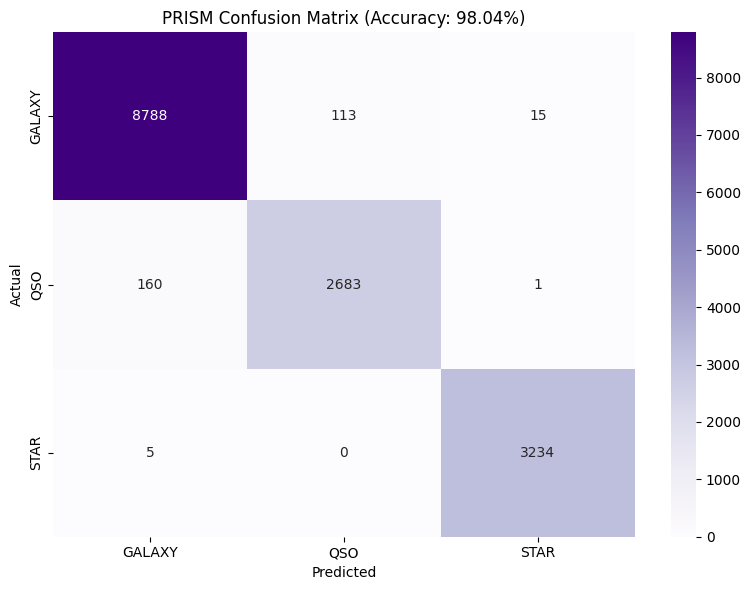

In [6]:
# Stage 3: Calibrated LightGBM

# Optimized LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.05,
    reg_lambda=0.05,
    random_state=42,
    verbose=-1
)

# Apply isotonic calibration
calibrated_lgb = CalibratedClassifierCV(lgb_model, method='isotonic', cv=3)
calibrated_lgb.fit(X_train_att, y_train)

# Evaluate
y_pred_test = calibrated_lgb.predict(X_test_att)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"\n✅ Stage 3: Calibrated LightGBM trained")
print(f"PRISM FINAL TEST ACCURACY: {test_acc:.4f} ({test_acc*100:.2f}%)\n")

print("\n PRISM Classification Report (Test Set):")
print(classification_report(y_test, y_pred_test, target_names=label_encoder.classes_))

# Confusion Matrix
cm_prism = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_prism, annot=True, fmt='d', cmap='Purples',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'PRISM Confusion Matrix (Accuracy: {test_acc*100:.2f}%)')
plt.tight_layout()
plt.savefig('../visualizations/prism_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


FINAL MODEL COMPARISON

        Model  Test Accuracy Improvement over RF
Random Forest       0.978200            Baseline
      XGBoost       0.978532              0.033%
        PRISM       0.980399              0.220%


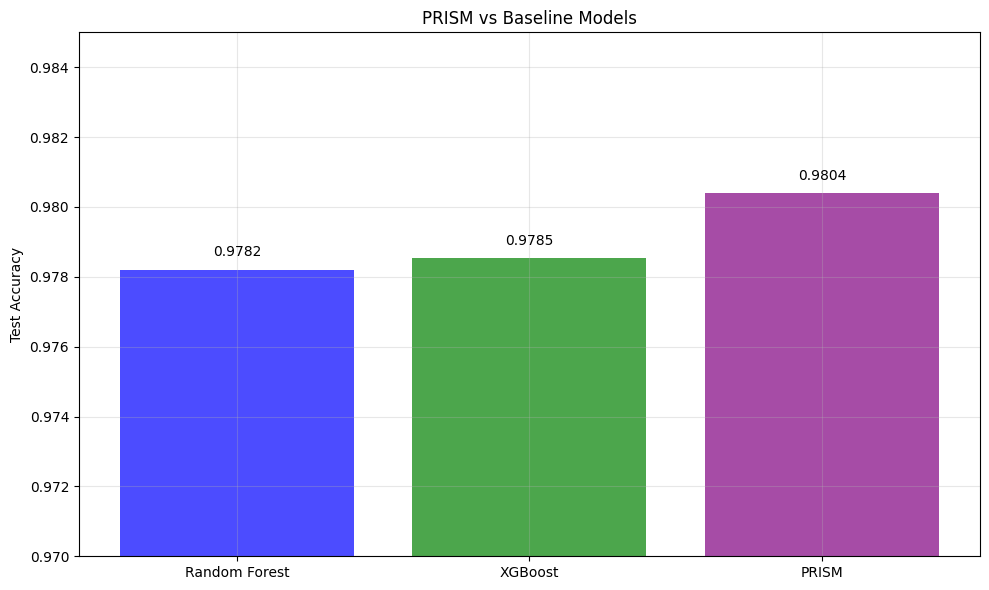

In [7]:
# Final Comparison

comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'PRISM'],
    'Test Accuracy': [rf_test_acc, xgb_test_acc, test_acc],
    'Improvement over RF': ['Baseline', 
                           f"{(xgb_test_acc - rf_test_acc)*100:.3f}%", 
                           f"{(test_acc - rf_test_acc)*100:.3f}%"]
})

print("FINAL MODEL COMPARISON\n")
print(comparison.to_string(index=False))

# Bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(comparison['Model'], comparison['Test Accuracy'], 
               color=['blue', 'green', 'purple'], alpha=0.7)
plt.ylabel('Test Accuracy')
plt.title('PRISM vs Baseline Models')
plt.ylim(0.97, 0.985)
plt.grid(True, alpha=0.3)

for bar, acc in zip(bars, comparison['Test Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003, 
             f'{acc:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../visualizations/prism_final_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


In [8]:
# Save PRISM Model

prism_pipeline = {
    'graph_encoder': graph_encoder,
    'attention': attention,
    'classifier': calibrated_lgb,
    'feature_names': feature_names,
    'label_encoder': label_encoder,
    'attention_weights': attention.weights
}

joblib.dump(prism_pipeline, '../models/prism_model.pkl', protocol=4)
print("\n✅ PRISM model saved to models/prism_model.pkl")

# Save results
prism_results = pd.DataFrame({
    'Metric': ['Test Accuracy', 'GALAXY F1', 'QSO F1', 'STAR F1'],
    'Value': [test_acc, 
              f1_score(y_test, y_pred_test, average=None)[0],
              f1_score(y_test, y_pred_test, average=None)[1],
              f1_score(y_test, y_pred_test, average=None)[2]]
})
prism_results.to_csv('../models/prism_results.csv', index=False)
comparison.to_csv('../models/final_comparison.csv', index=False)

print("✅ Results saved to models/prism_results.csv")
print("✅ Final comparison saved to models/final_comparison.csv")


✅ PRISM model saved to models/prism_model.pkl
✅ Results saved to models/prism_results.csv
✅ Final comparison saved to models/final_comparison.csv
